In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix 

In [3]:
df = pd.read_csv("breastcancer.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [7]:
df.drop(['id','Unnamed: 32'],axis=1,inplace=True)

In [9]:
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [10]:
df['diagnosis']=df['diagnosis'].map({'M':0,'B':1})

In [11]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [12]:
X = df.drop(['diagnosis'],axis=1)
y = df['diagnosis']

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
model1 = AdaBoostClassifier(n_estimators=100,random_state=42)
model1.fit(X_train,y_train)
y_pred1=model1.predict(X_test)
print("accuracy:",accuracy_score(y_test,y_pred1))
print(classification_report(y_test,y_pred1))
print('confusion_matrix:',confusion_matrix(y_test,y_pred1))

accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

confusion_matrix: [[41  2]
 [ 1 70]]


In [18]:
model2 = GradientBoostingClassifier()
model2.fit(X_train,y_train)
y_pred2=model2.predict(X_test)
print("accuracy:",accuracy_score(y_test,y_pred2))
print(classification_report(y_test,y_pred2))
print('confusion_matrix:',confusion_matrix(y_test,y_pred2))

accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

confusion_matrix: [[40  3]
 [ 2 69]]


In [19]:
model3 = XGBClassifier()
model3.fit(X_train,y_train)
y_pred3=model3.predict(X_test)
print("accuracy:",accuracy_score(y_test,y_pred3))
print(classification_report(y_test,y_pred3))
print('confusion_matrix:',confusion_matrix(y_test,y_pred3))

accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

confusion_matrix: [[40  3]
 [ 2 69]]


In [20]:
model4=CatBoostClassifier()
model4.fit(X_train,y_train)
y_pred4 = model4.predict(X_test)
print("accuracy:",accuracy_score(y_test,y_pred4))
print(classification_report(y_test,y_pred4))
print('confusion_matrix:',confusion_matrix(y_test,y_pred4))

Learning rate set to 0.00736
0:	learn: 0.6812707	total: 64ms	remaining: 1m 3s
1:	learn: 0.6692553	total: 69.6ms	remaining: 34.7s
2:	learn: 0.6584001	total: 73.5ms	remaining: 24.4s
3:	learn: 0.6482154	total: 76.7ms	remaining: 19.1s
4:	learn: 0.6375285	total: 79.6ms	remaining: 15.8s
5:	learn: 0.6284122	total: 82ms	remaining: 13.6s
6:	learn: 0.6165951	total: 84ms	remaining: 11.9s
7:	learn: 0.6064602	total: 85.9ms	remaining: 10.7s
8:	learn: 0.5955531	total: 87.9ms	remaining: 9.68s
9:	learn: 0.5862556	total: 89.9ms	remaining: 8.9s
10:	learn: 0.5759064	total: 92ms	remaining: 8.27s
11:	learn: 0.5665626	total: 94ms	remaining: 7.74s
12:	learn: 0.5565223	total: 95.7ms	remaining: 7.27s
13:	learn: 0.5480549	total: 97.6ms	remaining: 6.88s
14:	learn: 0.5396360	total: 99.5ms	remaining: 6.53s
15:	learn: 0.5311919	total: 101ms	remaining: 6.22s
16:	learn: 0.5238194	total: 103ms	remaining: 5.95s
17:	learn: 0.5156165	total: 105ms	remaining: 5.71s
18:	learn: 0.5084395	total: 106ms	remaining: 5.49s
19:	lear

In [21]:
model5 = LGBMClassifier()
model5.fit(X_train,y_train)
y_pred5 = model5.predict(X_test)
print("accuracy:",accuracy_score(y_test,y_pred5))
print(classification_report(y_test,y_pred5))
print('confusion_matrix:',confusion_matrix(y_test,y_pred5))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 286, number of negative: 169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000273 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628571 -> initscore=0.526093
[LightGBM] [Info] Start training from score 0.526093
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

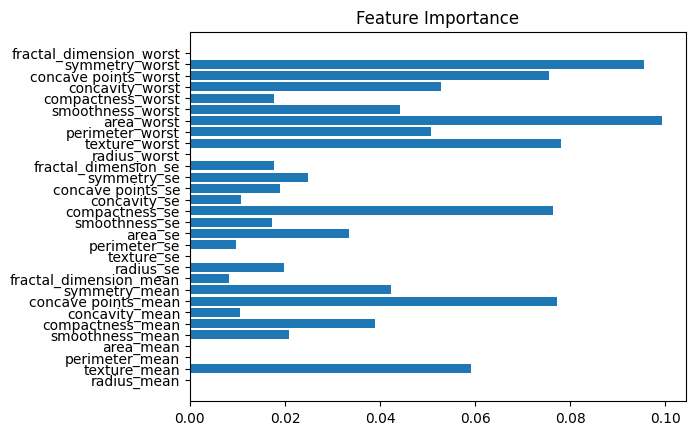

In [23]:
importance = model1.feature_importances_
plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()

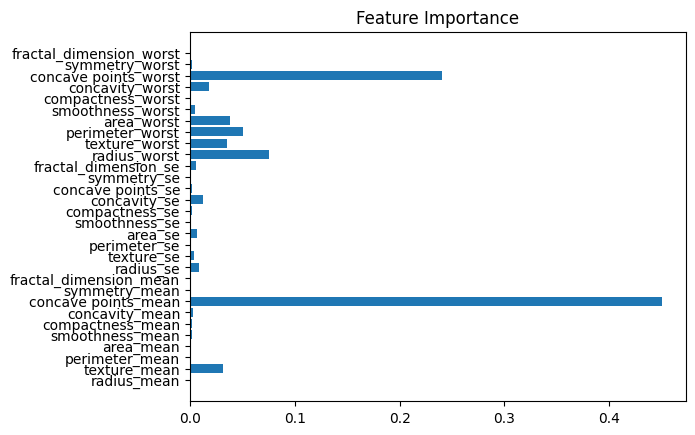

In [24]:
importance = model2.feature_importances_
plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()

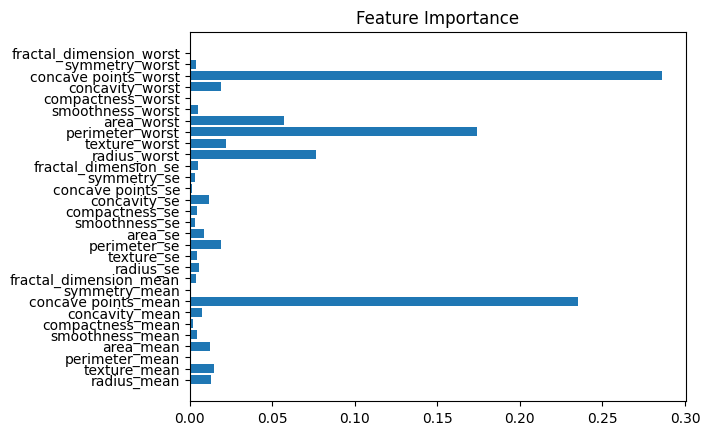

In [25]:
importance = model3.feature_importances_
plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()

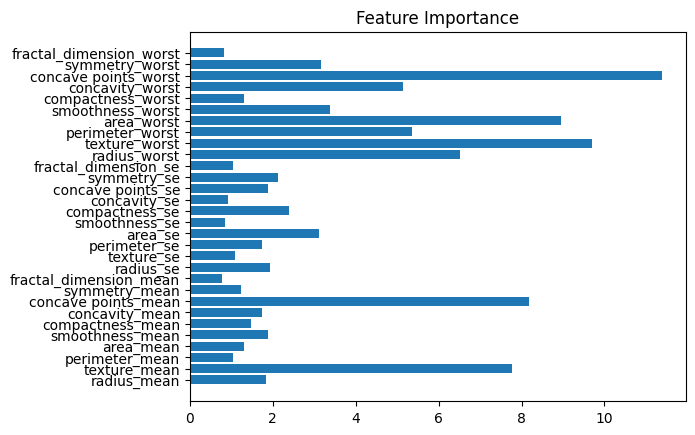

In [26]:
importance = model4.feature_importances_
plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()

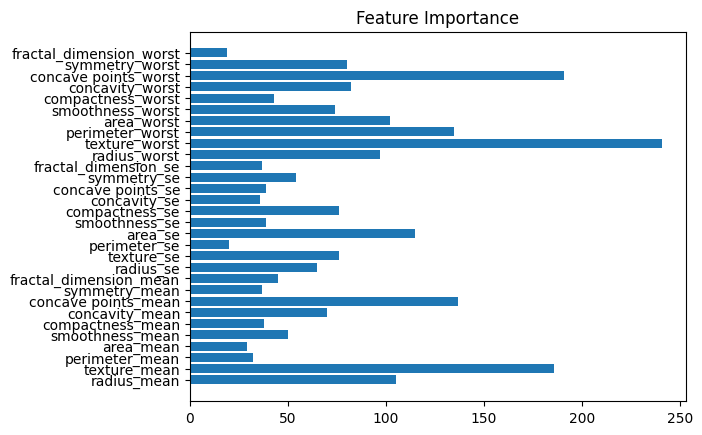

In [27]:
importance = model5.feature_importances_
plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()